# NYC Yellow Taxi Data Understanding (Q1 2025)

This notebook examines the final analysis-ready NYC Yellow Taxi dataset before model building.

## 1. Import Libraries and Load the Dataset

In [80]:
from pathlib import Path
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
import matplotlib.pyplot as plt

# Local folder containing the master dataset and model-ready outputs
MODEL_DATA_DIR = Path(r"C:\Asia Pacific University\All Module Notes\Semister-5\Investigations\FYP Semester 1\Progress\fyp\processed_outputs\model_datasets")

# Master analysis-ready dataset
MASTER_DATASET_PATH = MODEL_DATA_DIR / "nyc_yellow_taxi_master_analysis_ready_2025_q1.csv"

# Load the master dataset
df = pd.read_csv(MASTER_DATASET_PATH, parse_dates=["pickup_hour"])

display(df.head())
df.shape


,LocationID,borough,zone,service_zone,pickup_hour,hour,day_of_week,month,pickup_count,temperature_f,precipitation_in,subway_proximity_km,estimated_total_households,estimated_zero_vehicle_households,zero_vehicle_household_rate,zero_vehicle_rate_moe,zero_vehicle_rate_cv,census_reliability,census_coverage_ratio
0,2,Queens,Jamaica Bay,Boro Zone,2025-01-01 00:00:00,0,2,1,0,44.96,0.0,1.598622,17.772228,2.108158,0.118621,1.106223,5.669621,low,1.0
1,2,Queens,Jamaica Bay,Boro Zone,2025-01-01 01:00:00,1,2,1,0,44.96,0.0,1.598622,17.772228,2.108158,0.118621,1.106223,5.669621,low,1.0
2,2,Queens,Jamaica Bay,Boro Zone,2025-01-01 02:00:00,2,2,1,0,44.96,0.0,1.598622,17.772228,2.108158,0.118621,1.106223,5.669621,low,1.0
3,2,Queens,Jamaica Bay,Boro Zone,2025-01-01 03:00:00,3,2,1,0,46.94,0.0,1.598622,17.772228,2.108158,0.118621,1.106223,5.669621,low,1.0
4,2,Queens,Jamaica Bay,Boro Zone,2025-01-01 04:00:00,4,2,1,0,48.02,0.0,1.598622,17.772228,2.108158,0.118621,1.106223,5.669621,low,1.0


(559181, 19)

**Interpretation:** The analysis-ready master dataset is loaded with the hourly taxi demand, temporal variables, weather variables, spatial identifiers, contextual features, and Census quality fields required for Data Understanding.

## 2. Dataset Observations

In [81]:
zone_counts = df.groupby("LocationID").size()

observation_summary = pd.DataFrame({
    "Measure": [
        "Rows",
        "Columns",
        "Taxi zones",
        "Unique hourly timestamps",
        "Study start",
        "Study end",
        "Rows per zone - minimum",
        "Rows per zone - maximum",
        "Duplicate zone-hour records",
        "Missing cells"
    ],
    "Result": [
        len(df),
        df.shape[1],
        df["LocationID"].nunique(),
        df["pickup_hour"].nunique(),
        df["pickup_hour"].min(),
        df["pickup_hour"].max(),
        zone_counts.min(),
        zone_counts.max(),
        df.duplicated(["LocationID", "pickup_hour"]).sum(),
        df.isna().sum().sum()
    ]
})

display(observation_summary)

,Measure,Result
0,Rows,559181
1,Columns,19
2,Taxi zones,259
3,Unique hourly timestamps,2159
4,Study start,2025-01-01 00:00:00
5,Study end,2025-03-31 23:00:00
6,Rows per zone - minimum,2159
7,Rows per zone - maximum,2159
8,Duplicate zone-hour records,0
9,Missing cells,0


**Interpretation:** Each modelling observation represents one taxi zone at one hourly timestamp. Taxi-demand analysis therefore uses zone-hour rows, weather summaries use one record per unique hour, and static contextual variables are examined once per taxi zone.

## 3. Hourly Taxi Demand Distribution

In [82]:
pickups = df["pickup_count"]

target_statistics = pd.DataFrame({
    "Statistic": [
        "Total pickups",
        "Mean",
        "Standard deviation",
        "Minimum",
        "25th percentile",
        "Median",
        "75th percentile",
        "90th percentile",
        "95th percentile",
        "99th percentile",
        "Maximum",
        "Skewness",
        "Zero-demand zone-hours",
        "Zero-demand zone-hours (%)"
    ],
    "Value": [
        pickups.sum(),
        pickups.mean(),
        pickups.std(),
        pickups.min(),
        pickups.quantile(0.25),
        pickups.quantile(0.50),
        pickups.quantile(0.75),
        pickups.quantile(0.90),
        pickups.quantile(0.95),
        pickups.quantile(0.99),
        pickups.max(),
        pickups.skew(),
        pickups.eq(0).sum(),
        pickups.eq(0).mean() * 100
    ]
})

display(target_statistics)

zero_demand_zones = (
    df.groupby(["LocationID", "borough", "zone"], as_index=False)["pickup_count"]
      .sum()
      .query("pickup_count == 0")
)

display(zero_demand_zones)

,Statistic,Value
0,Total pickups,1.021862e+07
1,Mean,1.827426e+01
2,Standard deviation,5.487505e+01
3,Minimum,0.000000e+00
4,25th percentile,0.000000e+00
5,Median,1.000000e+00
6,75th percentile,4.000000e+00
7,90th percentile,5.200000e+01
8,95th percentile,1.240000e+02
9,99th percentile,2.790000e+02


,LocationID,borough,zone,pickup_count
42,44,Staten Island,Charleston/Tottenville,0
105,110,Staten Island,Great Kills Park,0


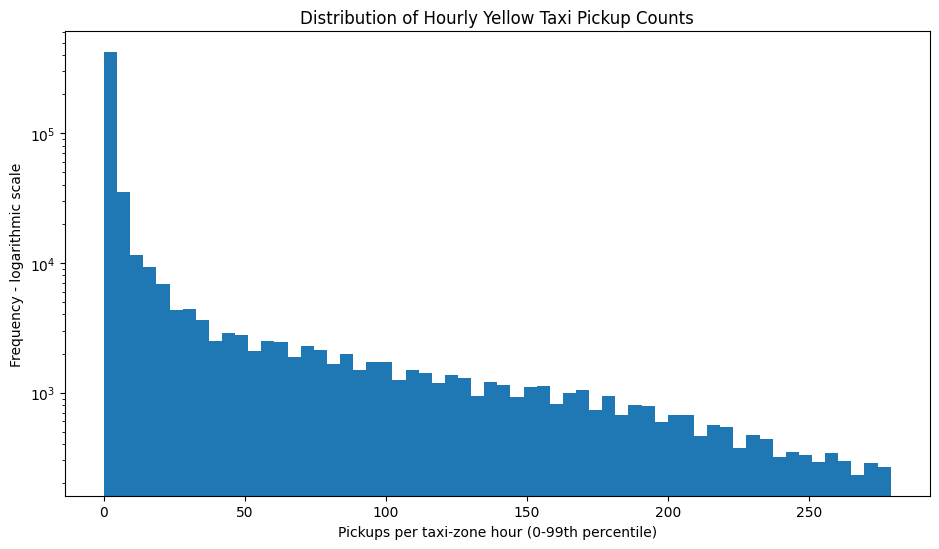

In [83]:
upper_99 = pickups.quantile(0.99)

fig, ax = plt.subplots(figsize=(9.5, 5.6))
ax.hist(df.loc[pickups <= upper_99, "pickup_count"], bins=60)
ax.set_yscale("log")
ax.set_xlabel("Pickups per taxi-zone hour (0-99th percentile)")
ax.set_ylabel("Frequency - logarithmic scale")
ax.set_title("Distribution of Hourly Yellow Taxi Pickup Counts")
plt.tight_layout()
plt.show()

**Interpretation:** The target is strongly right-skewed, with a large concentration of zero and very low pickup counts together with a much smaller high-demand tail.

## 4. Temporal Taxi Demand Patterns

### 4.1 Demand by Hour of Day

In [84]:
hour_summary = (
    df.groupby("hour")["pickup_count"]
      .agg(mean_pickups="mean", median_pickups="median", total_pickups="sum")
      .reset_index()
)

display(hour_summary)

hour_extremes = pd.DataFrame({
    "Measure": ["Lowest mean-demand hour", "Highest mean-demand hour"],
    "Hour": [
        int(hour_summary.loc[hour_summary["mean_pickups"].idxmin(), "hour"]),
        int(hour_summary.loc[hour_summary["mean_pickups"].idxmax(), "hour"])
    ],
    "Mean pickups": [
        hour_summary["mean_pickups"].min(),
        hour_summary["mean_pickups"].max()
    ]
})

display(hour_extremes)

,hour,mean_pickups,median_pickups,total_pickups
0,0,13.147233,0.0,306462
1,1,8.742686,0.0,203792
2,2,5.676977,0.0,130860
3,3,3.898584,0.0,90876
4,4,2.896396,0.0,67515
5,5,3.046976,1.0,71025
6,6,6.298241,1.0,146812
7,7,12.506607,2.0,291529
8,8,17.408366,2.0,405789
9,9,18.110468,1.0,422155


,Measure,Hour,Mean pickups
0,Lowest mean-demand hour,4,2.896396
1,Highest mean-demand hour,18,31.237967


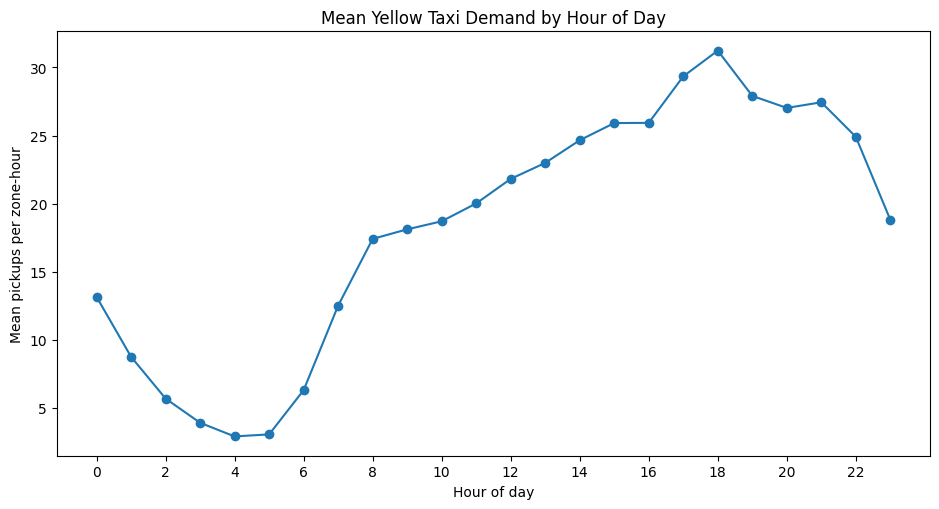

In [85]:
fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.plot(hour_summary["hour"], hour_summary["mean_pickups"], marker="o")
ax.set_xticks(range(0, 24, 2))
ax.set_xlabel("Hour of day")
ax.set_ylabel("Mean pickups per zone-hour")
ax.set_title("Mean Yellow Taxi Demand by Hour of Day")
plt.tight_layout()
plt.show()

**Interpretation:** Taxi demand follows a clear daily cycle, falling to its lowest level in the early morning and reaching its strongest average level during the evening period.

### 4.2 Demand by Day of Week

In [86]:
day_labels = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

day_summary = (
    df.groupby("day_of_week")["pickup_count"]
      .agg(mean_pickups="mean", median_pickups="median", total_pickups="sum")
      .reindex(range(7))
      .reset_index()
)
day_summary["day"] = day_summary["day_of_week"].map(day_labels)

display(day_summary[["day_of_week", "day", "mean_pickups", "median_pickups", "total_pickups"]])

hour_day = (
    df.groupby(["day_of_week", "hour"])["pickup_count"]
      .mean()
      .unstack("hour")
      .reindex(range(7))
)

hour_day_long = hour_day.stack().rename("mean_pickups").reset_index()
highest_day_hour = hour_day_long.loc[hour_day_long["mean_pickups"].idxmax()].copy()
lowest_day_hour = hour_day_long.loc[hour_day_long["mean_pickups"].idxmin()].copy()

hour_day_extremes = pd.DataFrame({
    "Measure": ["Lowest day-hour combination", "Highest day-hour combination"],
    "Day": [day_labels[int(lowest_day_hour["day_of_week"])], day_labels[int(highest_day_hour["day_of_week"])]],
    "Hour": [int(lowest_day_hour["hour"]), int(highest_day_hour["hour"])],
    "Mean pickups": [lowest_day_hour["mean_pickups"], highest_day_hour["mean_pickups"]]
})

display(hour_day_extremes)

,day_of_week,day,mean_pickups,median_pickups,total_pickups
0,0,Monday,14.953346,1.0,1208350
1,1,Tuesday,17.556601,1.0,1309582
2,2,Wednesday,18.398129,1.0,1486716
3,3,Thursday,19.869246,1.0,1605594
4,4,Friday,19.197765,1.0,1551333
5,5,Saturday,20.879307,1.0,1687215
6,6,Sunday,17.006183,1.0,1369831


,Measure,Day,Hour,Mean pickups
0,Lowest day-hour combination,Tuesday,3,0.752574
1,Highest day-hour combination,Saturday,19,35.725869


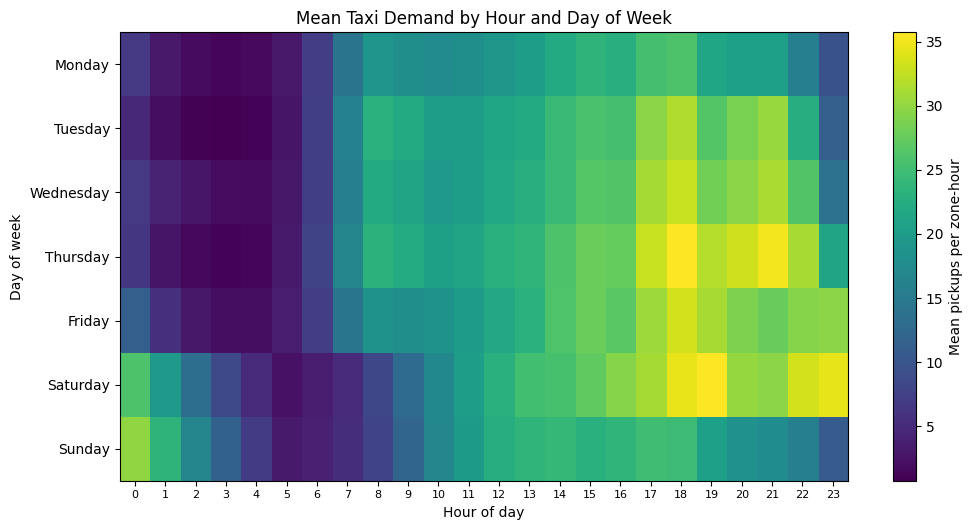

In [87]:
fig, ax = plt.subplots(figsize=(10.5, 5.4))
im = ax.imshow(hour_day.values, aspect="auto")
ax.set_xticks(range(24))
ax.set_xticklabels(range(24), fontsize=8)
ax.set_yticks(range(7))
ax.set_yticklabels([day_labels[i] for i in range(7)])
ax.set_xlabel("Hour of day")
ax.set_ylabel("Day of week")
ax.set_title("Mean Taxi Demand by Hour and Day of Week")
fig.colorbar(im, ax=ax, label="Mean pickups per zone-hour")
plt.tight_layout()
plt.show()

**Interpretation:** The heatmap shows that the hourly demand cycle changes across the week, with stronger late-afternoon and evening activity on several days and different weekend behaviour.

### 4.3 Demand by Month

In [88]:
month_labels = {1: "January", 2: "February", 3: "March"}

month_summary = (
    df.groupby("month")["pickup_count"]
      .agg(mean_pickups="mean", median_pickups="median", total_pickups="sum")
      .reset_index()
)
month_summary["month_name"] = month_summary["month"].map(month_labels)

display(month_summary[["month", "month_name", "mean_pickups", "median_pickups", "total_pickups"]])

,month,month_name,mean_pickups,median_pickups,total_pickups
0,1,January,16.577272,0.0,3194374
1,2,February,18.700376,1.0,3254763
2,3,March,19.588146,1.0,3769484


**Interpretation:** The three months provide the model with the temporal position within Q1 2025, but they are not sufficient to represent a complete annual seasonal pattern.

## 5. Spatial Variation in Taxi Demand

### 5.1 Demand by Borough

In [89]:
borough_summary = (
    df.groupby("borough")
      .agg(
          taxi_zones=("LocationID", "nunique"),
          total_pickups=("pickup_count", "sum"),
          mean_zone_hour_demand=("pickup_count", "mean"),
          median_zone_hour_demand=("pickup_count", "median")
      )
      .sort_values("total_pickups", ascending=False)
)
borough_summary["pickup_share_percent"] = (
    borough_summary["total_pickups"] / borough_summary["total_pickups"].sum() * 100
)

display(borough_summary.reset_index())

,borough,taxi_zones,total_pickups,mean_zone_hour_demand,median_zone_hour_demand,pickup_share_percent
0,Manhattan,66,9055323,63.548802,24.0,88.615900
1,Queens,69,846034,5.679186,0.0,8.279336
2,Brooklyn,61,253825,1.927312,1.0,2.483946
3,Bronx,43,62677,0.675130,0.0,0.613361
4,Staten Island,20,762,0.017647,0.0,0.007457


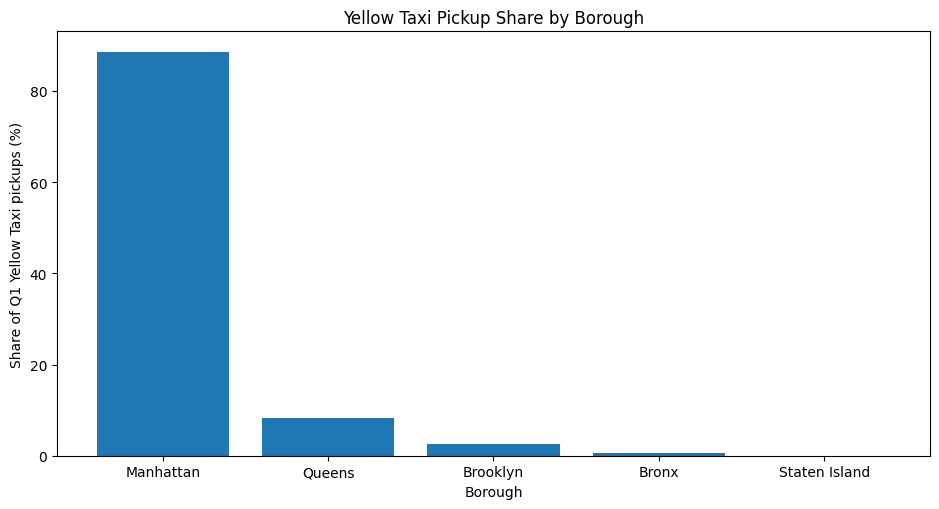

In [90]:
plot_borough = borough_summary.reset_index()

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.bar(plot_borough["borough"], plot_borough["pickup_share_percent"])
ax.set_xlabel("Borough")
ax.set_ylabel("Share of Q1 Yellow Taxi pickups (%)")
ax.set_title("Yellow Taxi Pickup Share by Borough")
plt.tight_layout()
plt.show()

**Interpretation:** Yellow Taxi demand is highly concentrated in Manhattan, showing why aggregate citywide model metrics can be dominated by a relatively small spatial part of the study area.

### 5.2 Demand by Taxi Zone

In [91]:
zone_summary = (
    df.groupby(["LocationID", "borough", "zone"], as_index=False)["pickup_count"]
      .agg(mean_hourly_demand="mean", median_hourly_demand="median", total_pickups="sum")
)

zone_distribution = zone_summary["mean_hourly_demand"].describe(percentiles=[0.25, 0.50, 0.75, 0.90]).to_frame("mean_hourly_demand")
zone_demand_skewness = zone_summary["mean_hourly_demand"].skew()

display(zone_distribution)
display(pd.DataFrame({"Statistic": ["Mean hourly demand across zones", "Median hourly demand across zones", "Skewness"], "Value": [zone_summary["mean_hourly_demand"].mean(), zone_summary["mean_hourly_demand"].median(), zone_demand_skewness]}))

display(zone_summary.sort_values("mean_hourly_demand", ascending=False).head(10))

borough_zone_median = (
    zone_summary.groupby("borough")["mean_hourly_demand"]
                .median()
                .rename("median_zone_mean_hourly_demand")
                .sort_values(ascending=False)
                .reset_index()
)
display(borough_zone_median)

,mean_hourly_demand
count,259.000000
mean,18.274264
std,41.575428
min,0.000000
25%,0.364521
50%,1.057434
75%,5.210977
90%,75.826401
max,221.850857


,Statistic,Value
0,Mean hourly demand across zones,18.274264
1,Median hourly demand across zones,1.057434
2,Skewness,2.761387


,LocationID,borough,zone,mean_hourly_demand,median_hourly_demand,total_pickups
156,161,Manhattan,Midtown Center,221.850857,196.0,478976
232,237,Manhattan,Upper East Side South,215.817045,233.0,465949
231,236,Manhattan,Upper East Side North,199.431681,207.0,430573
127,132,Queens,JFK Airport,175.194071,156.0,378244
225,230,Manhattan,Times Sq/Theatre District,160.082446,147.0,345618
181,186,Manhattan,Penn Station/Madison Sq West,158.851320,174.0,342960
157,162,Manhattan,Midtown East,156.731357,150.0,338383
137,142,Manhattan,Lincoln Square East,144.075035,159.0,311058
229,234,Manhattan,Union Sq,134.404354,127.0,290179
165,170,Manhattan,Murray Hill,129.592867,141.0,279791


,borough,median_zone_mean_hourly_demand
0,Manhattan,52.658175
1,Brooklyn,1.300139
2,Queens,0.701714
3,Bronx,0.635943
4,Staten Island,0.008569


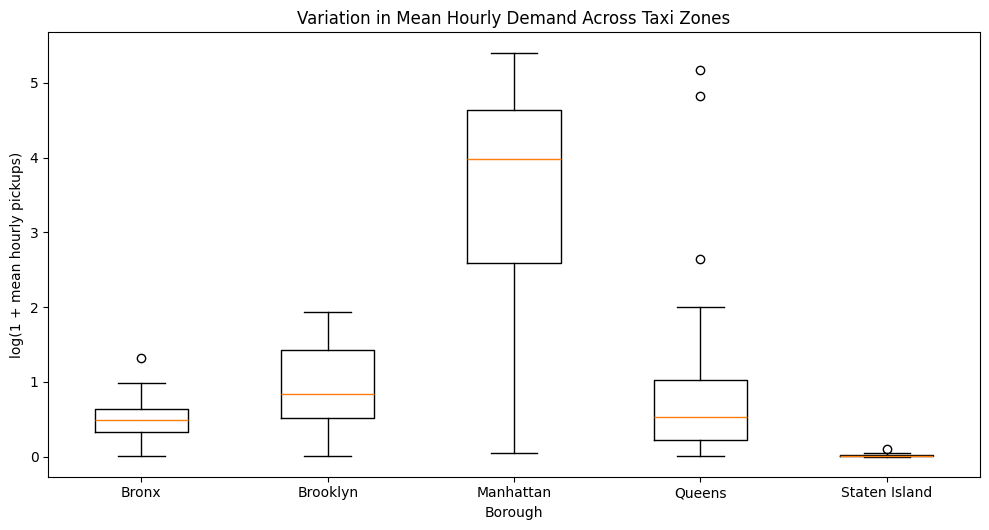

In [92]:
borough_order = ["Bronx", "Brooklyn", "Manhattan", "Queens", "Staten Island"]
box_data = [
    np.log1p(zone_summary.loc[zone_summary["borough"] == borough, "mean_hourly_demand"].values)
    for borough in borough_order
]

fig, ax = plt.subplots(figsize=(10.0, 5.4))
ax.boxplot(box_data, tick_labels=borough_order, showfliers=True)
ax.set_xlabel("Borough")
ax.set_ylabel("log(1 + mean hourly pickups)")
ax.set_title("Variation in Mean Hourly Demand Across Taxi Zones")
plt.tight_layout()
plt.show()

**Interpretation:** Mean hourly demand varies substantially between taxi zones and is strongly right-skewed. Most zones have relatively low average demand, while a smaller number of zones have very high demand. This supports evaluating model performance separately for individual taxi zones and leads directly to examining the zone-level contextual characteristics in the next section.

## 6. Contextual Taxi-Zone Characteristics

The spatial analysis above shows substantial differences in mean hourly demand between taxi zones. The contextual variables are therefore examined next at the same taxi-zone level because their values remain fixed across the hourly observations belonging to each zone.

In [93]:
zone_context = (
    df.sort_values(["LocationID", "pickup_hour"])
      .drop_duplicates("LocationID")
      [[
          "LocationID", "borough", "zone", "subway_proximity_km",
          "estimated_total_households", "estimated_zero_vehicle_households",
          "zero_vehicle_household_rate", "zero_vehicle_rate_moe",
          "zero_vehicle_rate_cv", "census_reliability", "census_coverage_ratio"
      ]]
      .merge(
          zone_summary[["LocationID", "mean_hourly_demand", "total_pickups"]],
          on="LocationID",
          how="left",
          validate="one_to_one"
      )
)

### 6.1 Subway Proximity

In [94]:
subway_statistics = zone_context["subway_proximity_km"].describe(percentiles=[0.25, 0.50, 0.75, 0.90]).to_frame("subway_proximity_km")
display(subway_statistics)

,subway_proximity_km
count,259.000000
mean,1.071409
std,1.386467
min,0.010463
25%,0.279048
50%,0.503514
75%,1.132808
90%,2.833500
max,7.571026


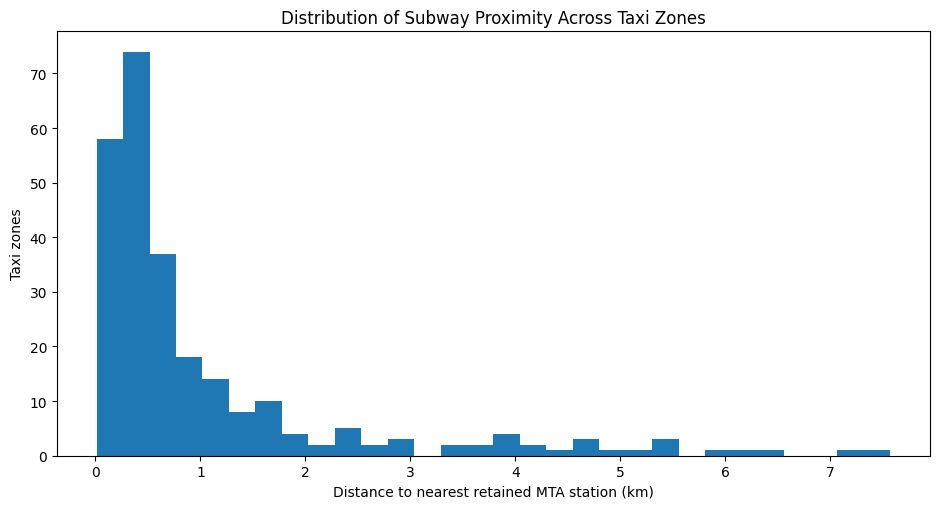

In [95]:
fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.hist(zone_context["subway_proximity_km"], bins=30)
ax.set_xlabel("Distance to nearest retained MTA station (km)")
ax.set_ylabel("Taxi zones")
ax.set_title("Distribution of Subway Proximity Across Taxi Zones")
plt.tight_layout()
plt.show()

**Interpretation:** Most taxi zones are relatively close to a retained MTA station, while a smaller group forms a long right tail of greater station distance.

### 6.2 Zero-Vehicle Household Rate

In [96]:
zero_vehicle_statistics = (zone_context["zero_vehicle_household_rate"] * 100).describe(percentiles=[0.25, 0.50, 0.75, 0.90]).to_frame("zero_vehicle_household_rate_percent")
display(zero_vehicle_statistics)

borough_zero_vehicle = (
    zone_context.assign(zero_vehicle_household_rate_percent=zone_context["zero_vehicle_household_rate"] * 100)
                .groupby("borough")["zero_vehicle_household_rate_percent"]
                .median()
                .rename("median_zero_vehicle_household_rate_percent")
                .sort_values(ascending=False)
                .reset_index()
)
display(borough_zero_vehicle)

,zero_vehicle_household_rate_percent
count,259.000000
mean,52.505625
std,24.821284
min,4.932150
25%,30.355691
50%,60.477542
75%,73.205458
90%,81.053892
max,92.921490


,borough,median_zero_vehicle_household_rate_percent
0,Manhattan,78.843552
1,Bronx,68.078261
2,Brooklyn,60.335749
3,Queens,26.348146
4,Staten Island,12.401551


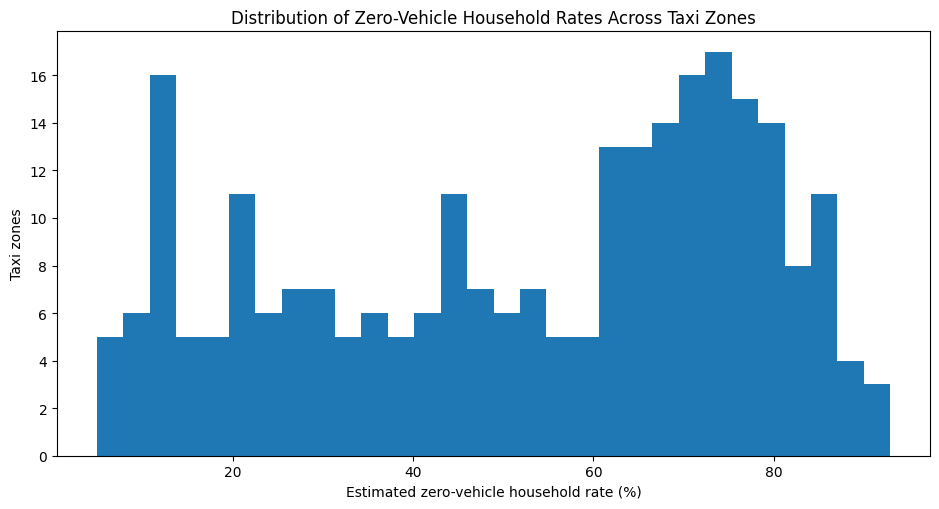

In [97]:
fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.hist(zone_context["zero_vehicle_household_rate"] * 100, bins=30)
ax.set_xlabel("Estimated zero-vehicle household rate (%)")
ax.set_ylabel("Taxi zones")
ax.set_title("Distribution of Zero-Vehicle Household Rates Across Taxi Zones")
plt.tight_layout()
plt.show()

**Interpretation:** Household vehicle availability varies widely across the taxi zones, providing substantial spatial variation for the planned contextual experiment.

### 6.3 Relationship Between Contextual Features and Zone-Level Demand

The zone-level demand distribution examined in Section 5.2 is strongly right-skewed, so Spearman rank correlation is used to describe monotonic associations with the contextual variables.

In [98]:
rho_subway, p_subway = spearmanr(zone_context["subway_proximity_km"], zone_context["mean_hourly_demand"])
rho_vehicle, p_vehicle = spearmanr(zone_context["zero_vehicle_household_rate"], zone_context["mean_hourly_demand"])
rho_context, p_context = spearmanr(zone_context["subway_proximity_km"], zone_context["zero_vehicle_household_rate"])

context_correlations = pd.DataFrame({
    "Relationship": [
        "Subway proximity vs mean hourly taxi demand",
        "Zero-vehicle household rate vs mean hourly taxi demand",
        "Subway proximity vs zero-vehicle household rate"
    ],
    "Spearman rho": [rho_subway, rho_vehicle, rho_context],
    "p-value": [p_subway, p_vehicle, p_context]
})

display(context_correlations)

display(
    zone_context.sort_values("mean_hourly_demand", ascending=False)
                [["LocationID", "borough", "zone", "mean_hourly_demand", "subway_proximity_km", "zero_vehicle_household_rate"]]
                .head(10)
)

,Relationship,Spearman rho,p-value
0,Subway proximity vs mean hourly taxi demand,-0.554745,2.649635e-22
1,Zero-vehicle household rate vs mean hourly tax...,0.684457,3.876126e-37
2,Subway proximity vs zero-vehicle household rate,-0.671491,2.586560e-35


,LocationID,borough,zone,mean_hourly_demand,subway_proximity_km,zero_vehicle_household_rate
156,161,Manhattan,Midtown Center,221.850857,0.314609,0.774472
232,237,Manhattan,Upper East Side South,215.817045,0.158020,0.613712
231,236,Manhattan,Upper East Side North,199.431681,0.159448,0.614567
127,132,Queens,JFK Airport,175.194071,3.993552,0.141306
225,230,Manhattan,Times Sq/Theatre District,160.082446,0.010463,0.929215
181,186,Manhattan,Penn Station/Madison Sq West,158.851320,0.162506,0.912997
157,162,Manhattan,Midtown East,156.731357,0.059382,0.861753
137,142,Manhattan,Lincoln Square East,144.075035,0.061020,0.746508
229,234,Manhattan,Union Sq,134.404354,0.142656,0.818661
165,170,Manhattan,Murray Hill,129.592867,0.354708,0.887115


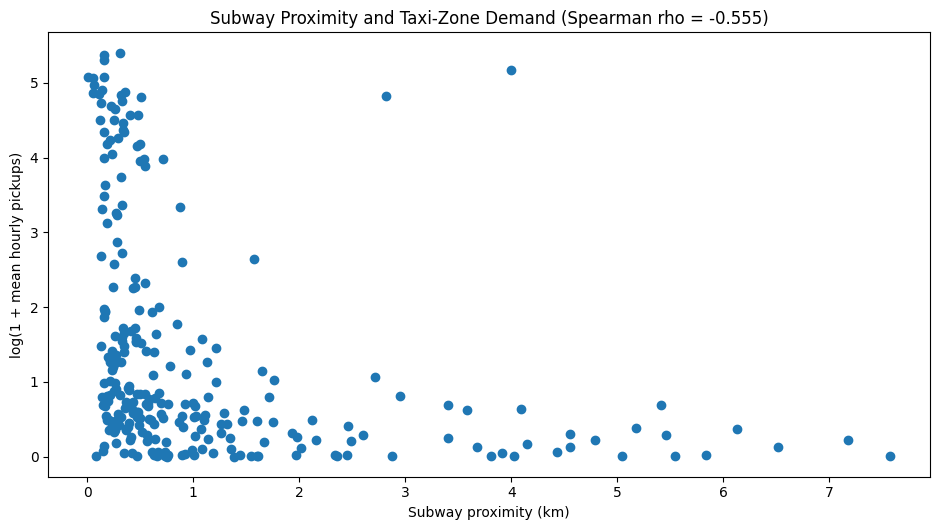

In [99]:
fig, ax = plt.subplots(figsize=(9.5, 5.4))
ax.scatter(zone_context["subway_proximity_km"], np.log1p(zone_context["mean_hourly_demand"]))
ax.set_xlabel("Subway proximity (km)")
ax.set_ylabel("log(1 + mean hourly pickups)")
ax.set_title(f"Subway Proximity and Taxi-Zone Demand (Spearman rho = {rho_subway:.3f})")
plt.tight_layout()
plt.show()

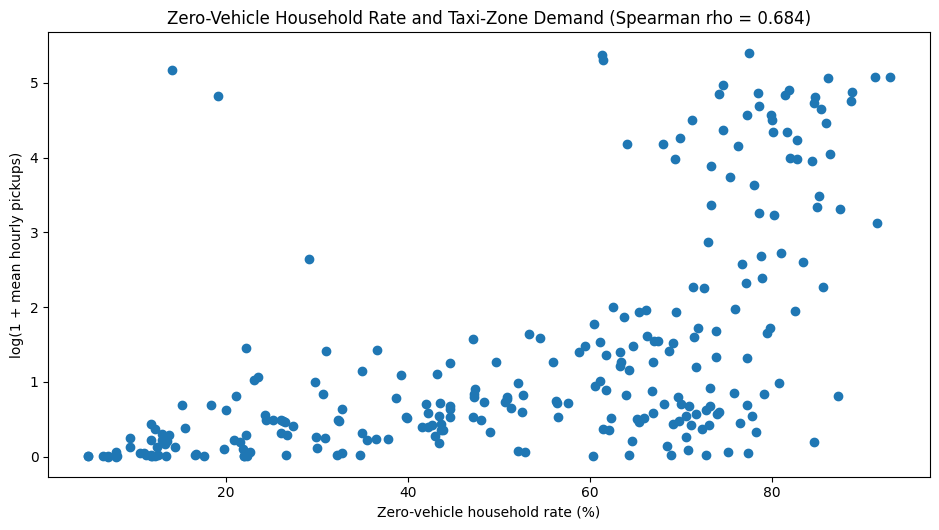

In [100]:
fig, ax = plt.subplots(figsize=(9.5, 5.4))
ax.scatter(zone_context["zero_vehicle_household_rate"] * 100, np.log1p(zone_context["mean_hourly_demand"]))
ax.set_xlabel("Zero-vehicle household rate (%)")
ax.set_ylabel("log(1 + mean hourly pickups)")
ax.set_title(f"Zero-Vehicle Household Rate and Taxi-Zone Demand (Spearman rho = {rho_vehicle:.3f})")
plt.tight_layout()
plt.show()

**Interpretation:** Both contextual variables show meaningful rank relationships with zone-level demand, but the scatterplots also contain clear exceptions. Their predictive contribution must therefore be tested through the controlled model experiments rather than inferred from correlation alone.

## 7. Weather Characteristics and Taxi Demand

Weather summaries are calculated from one observation per unique hourly timestamp because the same citywide weather value is repeated across all taxi zones for each hour.

### 7.1 Temperature

In [101]:
weather = (
    df[["pickup_hour", "temperature_f", "precipitation_in"]]
      .drop_duplicates("pickup_hour")
      .sort_values("pickup_hour")
)

temperature_statistics = weather["temperature_f"].describe().to_frame("temperature_f")
display(temperature_statistics)

,temperature_f
count,2159.000000
mean,37.805438
std,10.855660
min,10.940000
25%,30.020000
50%,37.040000
75%,46.040000
max,80.960000


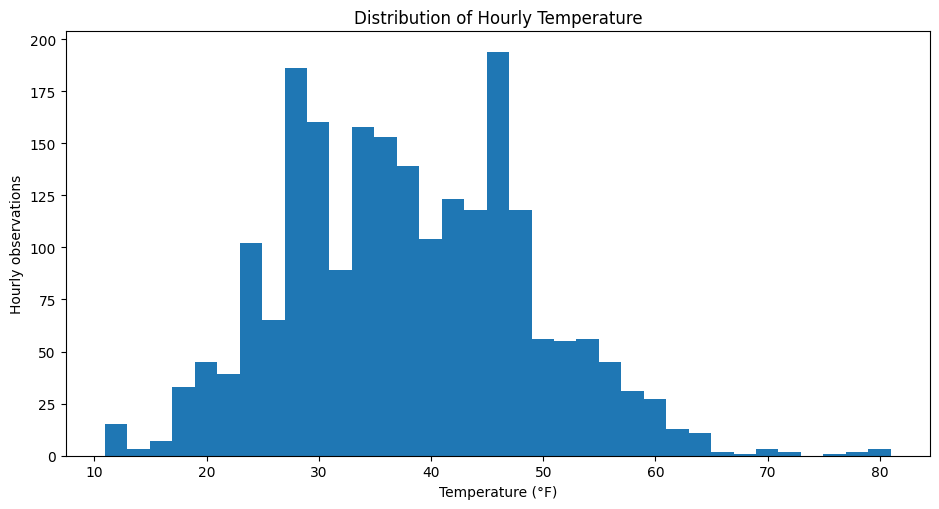

In [102]:
fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.hist(weather["temperature_f"], bins=35)
ax.set_xlabel("Temperature (°F)")
ax.set_ylabel("Hourly observations")
ax.set_title("Distribution of Hourly Temperature")
plt.tight_layout()
plt.show()

**Interpretation:** Temperature provides continuous hourly variation across the Q1 study period, although the observed range mainly represents winter and early-spring conditions.

### 7.2 Precipitation

In [103]:
precipitation_summary = pd.DataFrame({
    "Measure": [
        "Unique hourly observations",
        "No-precipitation hours",
        "No-precipitation hours (%)",
        "Positive-precipitation hours",
        "Positive-precipitation hours (%)",
        "Mean precipitation",
        "Median precipitation",
        "Median positive precipitation",
        "Maximum precipitation"
    ],
    "Value": [
        len(weather),
        weather["precipitation_in"].eq(0).sum(),
        weather["precipitation_in"].eq(0).mean() * 100,
        weather["precipitation_in"].gt(0).sum(),
        weather["precipitation_in"].gt(0).mean() * 100,
        weather["precipitation_in"].mean(),
        weather["precipitation_in"].median(),
        weather.loc[weather["precipitation_in"] > 0, "precipitation_in"].median(),
        weather["precipitation_in"].max()
    ]
})

display(precipitation_summary)

,Measure,Value
0,Unique hourly observations,2159.000000
1,No-precipitation hours,2019.000000
2,No-precipitation hours (%),93.515516
3,Positive-precipitation hours,140.000000
4,Positive-precipitation hours (%),6.484484
5,Mean precipitation,0.003959
6,Median precipitation,0.000000
7,Median positive precipitation,0.031496
8,Maximum precipitation,0.740157


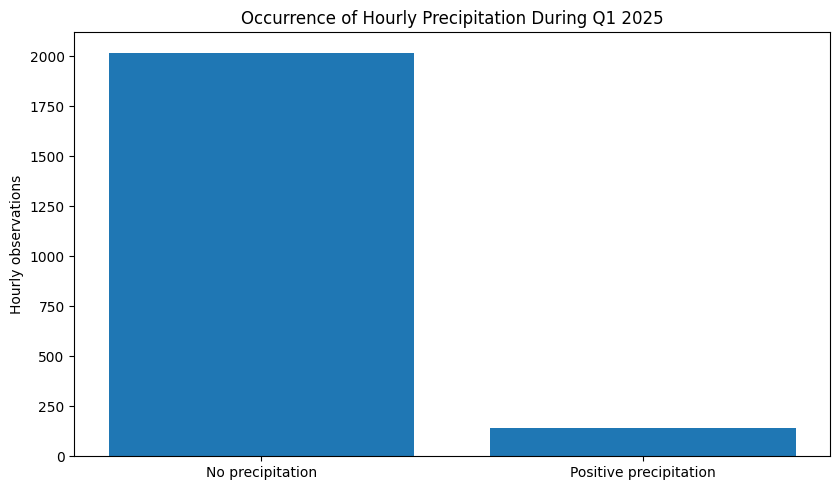

In [104]:
precipitation_occurrence = pd.Series({
    "No precipitation": weather["precipitation_in"].eq(0).sum(),
    "Positive precipitation": weather["precipitation_in"].gt(0).sum()
})

fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.bar(precipitation_occurrence.index, precipitation_occurrence.values)
ax.set_ylabel("Hourly observations")
ax.set_title("Occurrence of Hourly Precipitation During Q1 2025")
plt.tight_layout()
plt.show()

In [105]:
city_hourly_demand = (
    df.groupby("pickup_hour", as_index=False)["pickup_count"]
      .sum()
      .merge(weather, on="pickup_hour", how="left", validate="one_to_one")
)

weather_correlations = pd.DataFrame({
    "Relationship": [
        "Temperature vs citywide hourly pickups",
        "Precipitation vs citywide hourly pickups"
    ],
    "Pearson correlation": [
        pearsonr(city_hourly_demand["temperature_f"], city_hourly_demand["pickup_count"])[0],
        pearsonr(city_hourly_demand["precipitation_in"], city_hourly_demand["pickup_count"])[0]
    ]
})

display(weather_correlations)

,Relationship,Pearson correlation
0,Temperature vs citywide hourly pickups,0.193995
1,Precipitation vs citywide hourly pickups,0.098422


**Interpretation:** Positive precipitation is uncommon during the study period. The simple weather correlations are weak, but they do not rule out nonlinear relationships that can be learned by tree-based models.

## 8. Census Feature Reliability

In [106]:
reliability_order = ["high", "moderate", "low"]

reliability_summary = (
    zone_context["census_reliability"]
      .value_counts()
      .reindex(reliability_order, fill_value=0)
      .rename_axis("reliability")
      .reset_index(name="taxi_zones")
)
reliability_summary["percentage"] = reliability_summary["taxi_zones"] / len(zone_context) * 100

display(reliability_summary)

coverage_statistics = zone_context["census_coverage_ratio"].describe().to_frame("census_coverage_ratio")
display(coverage_statistics)

low_reliability_zones = (
    zone_context.loc[zone_context["census_reliability"].eq("low"), [
        "LocationID", "borough", "zone", "estimated_total_households",
        "zero_vehicle_household_rate", "zero_vehicle_rate_moe",
        "zero_vehicle_rate_cv", "census_coverage_ratio"
    ]]
    .sort_values("zero_vehicle_rate_cv", ascending=False)
)
display(low_reliability_zones)

,reliability,taxi_zones,percentage
0,high,208,80.308880
1,moderate,38,14.671815
2,low,13,5.019305


,census_coverage_ratio
count,259.000000
mean,0.999817
std,0.001180
min,0.987783
25%,1.000000
50%,1.000000
75%,1.000000
max,1.000000


,LocationID,borough,zone,estimated_total_households,zero_vehicle_household_rate,zero_vehicle_rate_moe,zero_vehicle_rate_cv,census_coverage_ratio
194,199,Bronx,Rikers Island,0.077942,0.220527,175.099916,482.721700,1.000000
105,110,Staten Island,Great Kills Park,3.360911,0.070905,4.132766,35.435133,1.000000
123,128,Manhattan,Inwood Hill Park,0.625222,0.528291,18.673309,21.489227,1.000000
6,8,Queens,Astoria Park,0.499532,0.642438,21.476563,20.323873,1.000000
106,111,Brooklyn,Green-Wood Cemetery,0.999460,0.603357,11.161591,11.246675,1.000000
97,99,Staten Island,Freshkills Park,24.414231,0.049370,0.806917,9.936623,1.000000
149,154,Brooklyn,Marine Park/Floyd Bennett Field,17.399030,0.079314,1.134466,8.695858,1.000000
0,2,Queens,Jamaica Bay,17.772228,0.118621,1.106223,5.669621,1.000000
127,132,Queens,JFK Airport,25.576968,0.141306,0.541438,2.329491,0.999994
248,253,Queens,Willets Point,7.273509,0.689065,1.386615,1.223400,1.000000


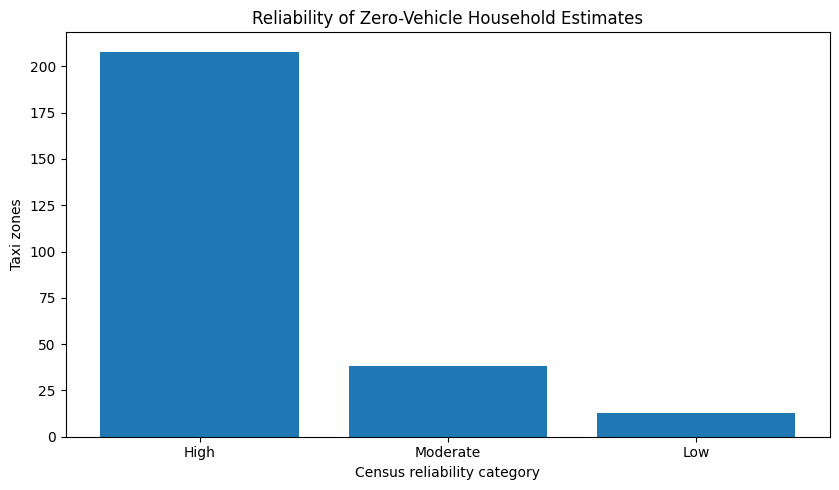

In [107]:
fig, ax = plt.subplots(figsize=(8.5, 5.0))
ax.bar(reliability_summary["reliability"].str.title(), reliability_summary["taxi_zones"])
ax.set_xlabel("Census reliability category")
ax.set_ylabel("Taxi zones")
ax.set_title("Reliability of Zero-Vehicle Household Estimates")
plt.tight_layout()
plt.show()

**Interpretation:** Most taxi-zone estimates fall in the high-reliability category, while the low-reliability cases are concentrated in a small group that can be retained for quality interpretation without adding the uncertainty measures as predictors.

## 9. Repeated Taxi-Zone Structure

In [108]:
repeated_zone_check = (
    df.groupby("LocationID")
      .agg(
          rows=("pickup_hour", "size"),
          unique_hours=("pickup_hour", "nunique"),
          unique_subway_values=("subway_proximity_km", "nunique"),
          unique_zero_vehicle_rates=("zero_vehicle_household_rate", "nunique")
      )
)

repeated_structure_summary = pd.DataFrame({
    "Check": [
        "Rows per LocationID - minimum",
        "Rows per LocationID - maximum",
        "Unique hours per LocationID - minimum",
        "Unique hours per LocationID - maximum",
        "Unique subway values within each zone - maximum",
        "Unique zero-vehicle rates within each zone - maximum",
        "Distinct subway values across zones",
        "Distinct zero-vehicle rates across zones"
    ],
    "Result": [
        repeated_zone_check["rows"].min(),
        repeated_zone_check["rows"].max(),
        repeated_zone_check["unique_hours"].min(),
        repeated_zone_check["unique_hours"].max(),
        repeated_zone_check["unique_subway_values"].max(),
        repeated_zone_check["unique_zero_vehicle_rates"].max(),
        zone_context["subway_proximity_km"].nunique(),
        zone_context["zero_vehicle_household_rate"].nunique()
    ]
})

display(repeated_structure_summary)

,Check,Result
0,Rows per LocationID - minimum,2159
1,Rows per LocationID - maximum,2159
2,Unique hours per LocationID - minimum,2159
3,Unique hours per LocationID - maximum,2159
4,Unique subway values within each zone - maximum,1
5,Unique zero-vehicle rates within each zone - m...,1
6,Distinct subway values across zones,259
7,Distinct zero-vehicle rates across zones,259


**Interpretation:** Every taxi zone is observed repeatedly through time, while the two contextual variables remain fixed within a zone. `LocationID` is therefore retained for grouping and zone-level evaluation rather than included in the primary predictor matrix.

## 10. Definition of Low-Demand Outer-Borough Zones

In [109]:
outer_boroughs = ["Bronx", "Brooklyn", "Queens", "Staten Island"]

zone_demand = (
    df.groupby(["LocationID", "borough", "zone"], as_index=False)["pickup_count"]
      .mean()
      .rename(columns={"pickup_count": "mean_hourly_demand"})
)

outer_zone_demand = zone_demand.loc[
    zone_demand["borough"].isin(outer_boroughs)
].copy()

q1 = outer_zone_demand["mean_hourly_demand"].quantile(0.25)
median = outer_zone_demand["mean_hourly_demand"].median()
q3 = outer_zone_demand["mean_hourly_demand"].quantile(0.75)

outer_zone_demand["demand_group"] = np.where(
    outer_zone_demand["mean_hourly_demand"] <= q1,
    "Low demand",
    "Other"
)

low_demand_outer = outer_zone_demand.loc[
    outer_zone_demand["demand_group"].eq("Low demand")
].copy()

low_demand_statistics = pd.DataFrame({
    "Measure": [
        "Outer-borough taxi zones",
        "Minimum mean hourly demand",
        "Mean hourly demand",
        "First quartile (Q1)",
        "Median",
        "Third quartile (Q3)",
        "Maximum mean hourly demand",
        "Skewness",
        "Low-demand outer-borough zones"
    ],
    "Value": [
        len(outer_zone_demand),
        outer_zone_demand["mean_hourly_demand"].min(),
        outer_zone_demand["mean_hourly_demand"].mean(),
        q1,
        median,
        q3,
        outer_zone_demand["mean_hourly_demand"].max(),
        outer_zone_demand["mean_hourly_demand"].skew(),
        len(low_demand_outer)
    ]
})

display(low_demand_statistics)

low_demand_by_borough = (
    low_demand_outer.groupby("borough")
                    .size()
                    .reindex(outer_boroughs, fill_value=0)
                    .rename("low_demand_zones")
                    .reset_index()
)

display(low_demand_by_borough)
display(low_demand_outer.sort_values(["borough", "mean_hourly_demand", "LocationID"]))

,Measure,Value
0,Outer-borough taxi zones,193.000000
1,Minimum mean hourly demand,0.000000
2,Mean hourly demand,2.791779
3,First quartile (Q1),0.245947
4,Median,0.690134
5,Third quartile (Q3),1.567855
6,Maximum mean hourly demand,175.194071
7,Skewness,10.012454
8,Low-demand outer-borough zones,49.000000


,borough,low_demand_zones
0,Bronx,8
1,Brooklyn,3
2,Queens,18
3,Staten Island,20


,LocationID,borough,zone,mean_hourly_demand,demand_group
194,199,Bronx,Rikers Island,0.002316,Low demand
57,59,Bronx,Crotona Park,0.021306,Low demand
179,184,Bronx,Pelham Bay Park,0.023159,Low demand
56,58,Bronx,Country Club,0.042149,Low demand
44,46,Bronx,City Island,0.048634,Low demand
29,31,Bronx,Bronx Park,0.069013,Low demand
235,240,Bronx,Van Cortlandt Park,0.087077,Low demand
178,183,Bronx,Pelham Bay,0.194071,Low demand
106,111,Brooklyn,Green-Wood Cemetery,0.008337,Low demand
149,154,Brooklyn,Marine Park/Floyd Bennett Field,0.062992,Low demand


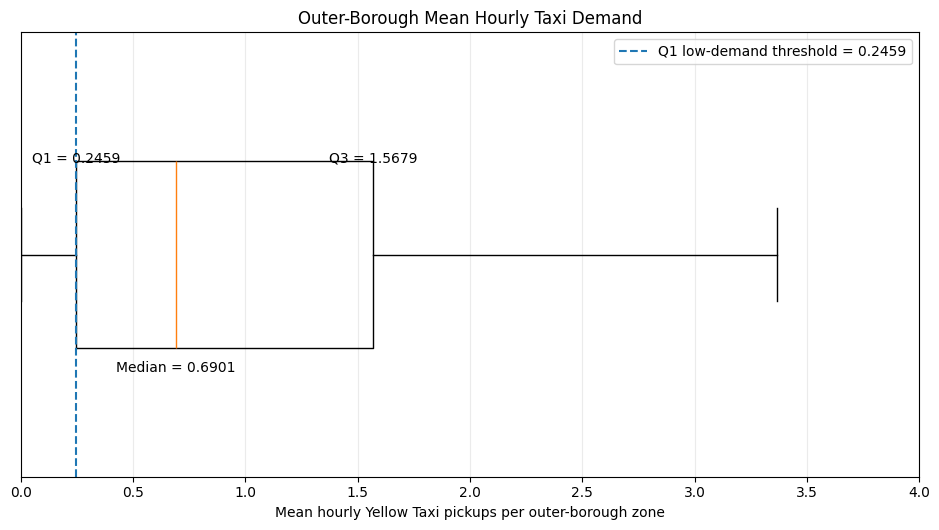

In [110]:
fig, ax = plt.subplots(figsize=(9.5, 5.4))

ax.boxplot(
    outer_zone_demand["mean_hourly_demand"],
    vert=False,
    showfliers=False,
    widths=0.42
)

ax.axvline(
    q1,
    linestyle="--",
    linewidth=1.5,
    label=f"Q1 low-demand threshold = {q1:.4f}"
)

ax.set_xlabel("Mean hourly Yellow Taxi pickups per outer-borough zone")
ax.set_yticks([])
ax.set_title("Outer-Borough Mean Hourly Taxi Demand")

upper_visible = q3 + 1.75 * (q3 - q1)
ax.set_xlim(left=0, right=max(4.0, upper_visible))

ax.text(q1, 1.20, f"Q1 = {q1:.4f}", ha="center", va="bottom")
ax.text(median, 0.76, f"Median = {median:.4f}", ha="center", va="top")
ax.text(q3, 1.20, f"Q3 = {q3:.4f}", ha="center", va="bottom")

ax.legend(loc="upper right")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

**Interpretation:** The outer-borough demand distribution is strongly right-skewed, so the low-demand group is defined using the first quartile rather than an arbitrary pickup-count cutoff. The box plot shows Q1, the median, and Q3 directly. Zones at or below Q1 form the lowest 25% of the outer-borough distribution. Outlier points are hidden only to keep the quartile box readable; they remain included in all calculations. The resulting low-demand label is used later for grouped model evaluation and is not used as a model predictor.

### 10.1 Reusable Evaluation Reference

The fixed outer-borough demand classification is retained in a separate two-column reference table for later zone-level model evaluation. `LocationID` is used only as the joining key and `demand_group` is used only as an evaluation category. Neither field is added to the Random Forest or XGBoost predictor matrices.


In [111]:
# Retain the fixed low-demand classification for later model evaluation
zone_evaluation_reference = (
    outer_zone_demand[["LocationID", "demand_group"]]
    .sort_values("LocationID")
    .reset_index(drop=True)
)

# Validate that every outer-borough zone has exactly one category
assert zone_evaluation_reference["LocationID"].is_unique
assert len(zone_evaluation_reference) == len(outer_zone_demand)
assert set(zone_evaluation_reference["demand_group"]) == {"Low demand", "Other"}

ZONE_EVALUATION_REFERENCE_PATH = (
    MODEL_DATA_DIR / "nyc_yellow_taxi_zone_evaluation_reference_2025_q1.csv"
)

zone_evaluation_reference.to_csv(
    ZONE_EVALUATION_REFERENCE_PATH,
    index=False
)

evaluation_reference_summary = pd.DataFrame({
    "Measure": [
        "Outer-borough zones retained",
        "Low-demand zones",
        "Other outer-borough zones",
        "Unique LocationIDs"
    ],
    "Value": [
        len(zone_evaluation_reference),
        zone_evaluation_reference["demand_group"].eq("Low demand").sum(),
        zone_evaluation_reference["demand_group"].eq("Other").sum(),
        zone_evaluation_reference["LocationID"].nunique()
    ]
})

display(evaluation_reference_summary)
display(zone_evaluation_reference.head())
print(f"Saved evaluation reference: {ZONE_EVALUATION_REFERENCE_PATH}")


,Measure,Value
0,Outer-borough zones retained,193
1,Low-demand zones,49
2,Other outer-borough zones,144
3,Unique LocationIDs,193


,LocationID,demand_group
0,2,Low demand
1,3,Other
2,5,Low demand
3,6,Low demand
4,7,Other


Saved evaluation reference: C:\Asia Pacific University\All Module Notes\Semister-5\Investigations\FYP Semester 1\Progress\fyp\processed_outputs\model_datasets\nyc_yellow_taxi_zone_evaluation_reference_2025_q1.csv


## 11. Prepare Baseline and Enriched Modelling Datasets


In [112]:
# Columns retained to identify each prediction later during zone-level evaluation
identifier_columns = [
    "LocationID",
    "borough",
    "zone",
    "pickup_hour"
]

target_column = "pickup_count"

# Baseline predictors: temporal + weather features
baseline_features = [
    "hour",
    "day_of_week",
    "month",
    "temperature_f",
    "precipitation_in"
]

# Contextual features added to the enriched dataset
contextual_features = [
    "subway_proximity_km",
    "zero_vehicle_household_rate"
]

# Create the baseline modelling dataset
baseline_model_dataset = df[
    identifier_columns + [target_column] + baseline_features
].copy()

# Create the enriched modelling dataset
enriched_model_dataset = df[
    identifier_columns + [target_column] + baseline_features + contextual_features
].copy()

# Output file paths
BASELINE_OUTPUT_PATH = MODEL_DATA_DIR / "nyc_yellow_taxi_baseline_model_dataset_2025_q1.csv"
ENRICHED_OUTPUT_PATH = MODEL_DATA_DIR / "nyc_yellow_taxi_enriched_model_dataset_2025_q1.csv"

# Save both model-ready datasets in the model_datasets folder
baseline_model_dataset.to_csv(BASELINE_OUTPUT_PATH, index=False)
enriched_model_dataset.to_csv(ENRICHED_OUTPUT_PATH, index=False)

# Confirm the datasets created for the Model Building phase
dataset_summary = pd.DataFrame({
    "Dataset": ["Baseline", "Enriched"],
    "Rows": [baseline_model_dataset.shape[0], enriched_model_dataset.shape[0]],
    "Columns": [baseline_model_dataset.shape[1], enriched_model_dataset.shape[1]],
    "Taxi Zones": [
        baseline_model_dataset["LocationID"].nunique(),
        enriched_model_dataset["LocationID"].nunique()
    ],
    "Model Predictors": [len(baseline_features), len(baseline_features + contextual_features)],
    "Saved File": [str(BASELINE_OUTPUT_PATH), str(ENRICHED_OUTPUT_PATH)]
})

display(dataset_summary)
display(baseline_model_dataset.head())
display(enriched_model_dataset.head())


,Dataset,Rows,Columns,Taxi Zones,Model Predictors,Saved File
0,Baseline,559181,10,259,5,C:\Asia Pacific University\All Module Notes\Se...
1,Enriched,559181,12,259,7,C:\Asia Pacific University\All Module Notes\Se...


,LocationID,borough,zone,pickup_hour,pickup_count,hour,day_of_week,month,temperature_f,precipitation_in
0,2,Queens,Jamaica Bay,2025-01-01 00:00:00,0,0,2,1,44.96,0.0
1,2,Queens,Jamaica Bay,2025-01-01 01:00:00,0,1,2,1,44.96,0.0
2,2,Queens,Jamaica Bay,2025-01-01 02:00:00,0,2,2,1,44.96,0.0
3,2,Queens,Jamaica Bay,2025-01-01 03:00:00,0,3,2,1,46.94,0.0
4,2,Queens,Jamaica Bay,2025-01-01 04:00:00,0,4,2,1,48.02,0.0


,LocationID,borough,zone,pickup_hour,pickup_count,hour,day_of_week,month,temperature_f,precipitation_in,subway_proximity_km,zero_vehicle_household_rate
0,2,Queens,Jamaica Bay,2025-01-01 00:00:00,0,0,2,1,44.96,0.0,1.598622,0.118621
1,2,Queens,Jamaica Bay,2025-01-01 01:00:00,0,1,2,1,44.96,0.0,1.598622,0.118621
2,2,Queens,Jamaica Bay,2025-01-01 02:00:00,0,2,2,1,44.96,0.0,1.598622,0.118621
3,2,Queens,Jamaica Bay,2025-01-01 03:00:00,0,3,2,1,46.94,0.0,1.598622,0.118621
4,2,Queens,Jamaica Bay,2025-01-01 04:00:00,0,4,2,1,48.02,0.0,1.598622,0.118621
